In [2]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS

__<font color=cyan>1.画movie 1</font>__

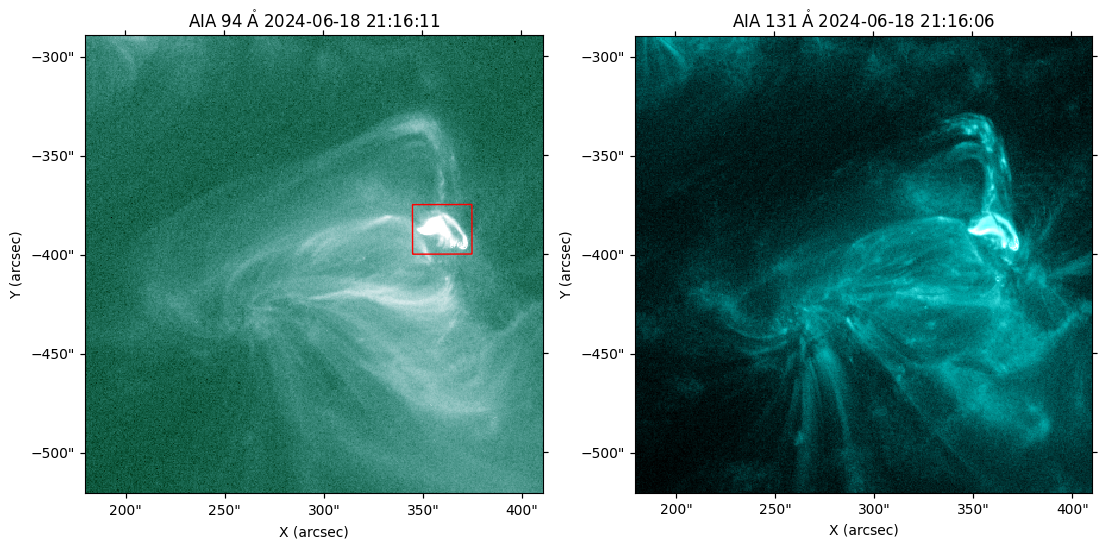

In [8]:
file_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\\'
file_list_94=glob.glob(file_path+'*94.*')
file_list_94.sort()
file_list_131=glob.glob(file_path+'*131.*')
file_list_131.sort()

i=321
map_94 = sunpy.map.Map(file_list_94[i])
map_131 = sunpy.map.Map(file_list_131[i])

bottom_left = SkyCoord(Tx=180*u.arcsec, Ty=-520*u.arcsec, frame=map_94.coordinate_frame)
top_right = SkyCoord(Tx=410*u.arcsec, Ty=-290*u.arcsec, frame=map_94.coordinate_frame)

smap_94 = map_94.submap(bottom_left, top_right=top_right)
smap_131 = map_131.submap(bottom_left, top_right=top_right)

fig = plt.figure(figsize=(13, 6))
ax1 = fig.add_subplot(1, 2, 1, projection=smap_94)
ax2 = fig.add_subplot(1, 2, 2, projection=smap_131)

norm_94 = smap_94.plot_settings['norm']
norm_94.vmax=300

norm_131 = smap_131.plot_settings['norm']
norm_131.vmin = 0.01
norm_131.vmax = 3000

smap_94.plot(axes=ax1, norm=norm_94)
smap_131.plot(axes=ax2, norm=norm_131)

bl2=SkyCoord(Tx=345*u.arcsec, Ty=-400*u.arcsec, frame=smap_94.coordinate_frame)
tr2=SkyCoord(Tx=375*u.arcsec, Ty=-375*u.arcsec, frame=smap_94.coordinate_frame)
smap_94.draw_quadrangle(bl2,top_right=tr2,edgecolor='red',axes=ax1)

ax1.coords[0].grid(draw_grid=False)
ax1.coords[1].grid(draw_grid=False)
ax2.coords[0].grid(draw_grid=False)
ax2.coords[1].grid(draw_grid=False)
ax1.set_xlabel('X (arcsec)',labelpad=1.1)
ax1.set_ylabel('Y (arcsec)')
ax2.set_xlabel('X (arcsec)')
ax2.set_ylabel('Y (arcsec)')

In [3]:
#这一段代码是画视频1的，从20：22到21：40，左边94，右边131的视频
file_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\\'
file_list_94=glob.glob(file_path+'*94.*')
file_list_94.sort()
file_list_131=glob.glob(file_path+'*131.*')
file_list_131.sort()

output_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\.94_131fig_all\\'
ref_map_94=sunpy.map.Map(file_list_94[281])
ref_map_131=sunpy.map.Map(file_list_131[281])
bottom_left = SkyCoord(Tx=180*u.arcsec, Ty=-520*u.arcsec, frame=ref_map_94.coordinate_frame)
top_right = SkyCoord(Tx=410*u.arcsec, Ty=-290*u.arcsec, frame=ref_map_94.coordinate_frame)
ref_smap_94=ref_map_94.submap(bottom_left, top_right=top_right)
ref_smap_131=ref_map_131.submap(bottom_left, top_right=top_right)
for i in range(66,len(file_list_94),5):
    if i not in [241,281,291]:
        map_94 = sunpy.map.Map(file_list_94[i])
        map_131 = sunpy.map.Map(file_list_131[i])

        with propagate_with_solar_surface():
            rot_smap_94 = map_94.reproject_to(ref_smap_94.wcs, preserve_date_obs=True)
            rot_smap_131 = map_131.reproject_to(ref_smap_131.wcs, preserve_date_obs=True)
        
        fig = plt.figure(figsize=(13, 6))
        ax1 = fig.add_subplot(1, 2, 1, projection=rot_smap_94)
        ax2 = fig.add_subplot(1, 2, 2, projection=rot_smap_131)

        norm_94 = rot_smap_94.plot_settings['norm']
        norm_94.vmax=300

        norm_131 = rot_smap_131.plot_settings['norm']
        norm_131.vmin = 0.01
        norm_131.vmax = 1800

        rot_smap_94.plot(axes=ax1, norm=norm_94)
        rot_smap_131.plot(axes=ax2, norm=norm_131)
        ax1.coords[0].grid(draw_grid=False)
        ax1.coords[1].grid(draw_grid=False)
        ax2.coords[0].grid(draw_grid=False)
        ax2.coords[1].grid(draw_grid=False)
        ax1.set_xlabel('X (arcsec)',labelpad=1.1)
        ax1.set_ylabel('Y (arcsec)')
        ax2.set_xlabel('X (arcsec)')
        ax2.set_ylabel('Y (arcsec)')
        ax1.coords[0].set_major_formatter('s',show_decimal_unit=False)
        ax1.coords[1].set_major_formatter('s',show_decimal_unit=False)
        ax2.coords[0].set_major_formatter('s',show_decimal_unit=False)
        ax2.coords[1].set_major_formatter('s',show_decimal_unit=False)
        plt.savefig(output_path+f'{i:03d}.png', dpi=250)
        plt.close()

__<font color=cyan>2.画图1</font>__

In [2]:
#这里dir1是pre_131.sav的目录对应0-31，dir2是131.sav的目录对应32-132，exptime是长148的观测时间
def aia_intensity_curve(dir1,dir2,dir3,exptime,wavelenth):
    from scipy.io import readsav
    #这部分先把数据读入进来
    matrices=[]
    data1=readsav(dir1)
    matrix_struct=data1['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    matrices=matrices[69:]#这一步是当时我matrices统一设置成大小为110了，所以存的数据都在后面
    data2=readsav(dir2)
    matrix_struct=data2['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    data3=readsav(dir3)
    matrix_struct=data3['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    #计算平均强度
    intensity=np.zeros(148)
    for i in range(148):
        intensity[i]=np.average(matrices[i])
    #这里去掉曝光时间不一致的点，131和193单独处理
    if wavelenth=='131' or '193':
        threshold=2.90 if wavelenth=='131' else 1.99
        #print(threshold)
        intensity[exptime[:]<threshold]=np.nan
        #把去掉的点用插值函数补上
        x=np.arange(148)
        valid_x=x[~np.isnan(intensity)]
        valid_intensity=intensity[~np.isnan(intensity)]
        f=interp1d(valid_x,valid_intensity,kind='linear')
        intensity[np.isnan(intensity)]=f(x[np.isnan(intensity)])
    #归一化
    intensity=(intensity-np.min(intensity))/(np.max(intensity)-np.min(intensity))
    return intensity

In [3]:
intensity=np.zeros((7,148))
name_list=['.94','131','171','193','211','304','335']

for i in range(7):
    path=os.path.join(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2',name_list[i],'*.fits')
    file_list=glob.glob(path)
    exptime=np.zeros(len(file_list))
    for j in range(len(file_list)):
        rsm=fits.open(file_list[j])
        exptime[j]=rsm[1].header['EXPTIME']

    dir1=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\pre_'+name_list[i]+'.sav'
    dir2=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'.sav'
    dir3=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\post_'+name_list[i]+'.sav'
    intensity[i,:]=aia_intensity_curve(dir1,dir2,dir3,exptime[:],name_list[i])
    #print(exptime[:133])

In [4]:
map1=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\aia.lev1_euv_12s.2024-06-18T204301Z.94.image_lev1.fits')
map2=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\aia.lev1_euv_12s.2024-06-18T211813Z.94.image_lev1.fits')
map3=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\aia.lev1_euv_12s.2024-06-18T213913Z.94.image_lev1.fits')
map4=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI4\Br_map.fits')
map5=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211644Z.131.image_lev1.fits')
map6=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211820Z.131.image_lev1.fits')
map7=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212244Z.131.image_lev1.fits')
map8=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\171\aia.lev1_euv_12s.2024-06-18T211822Z.171.image_lev1.fits')

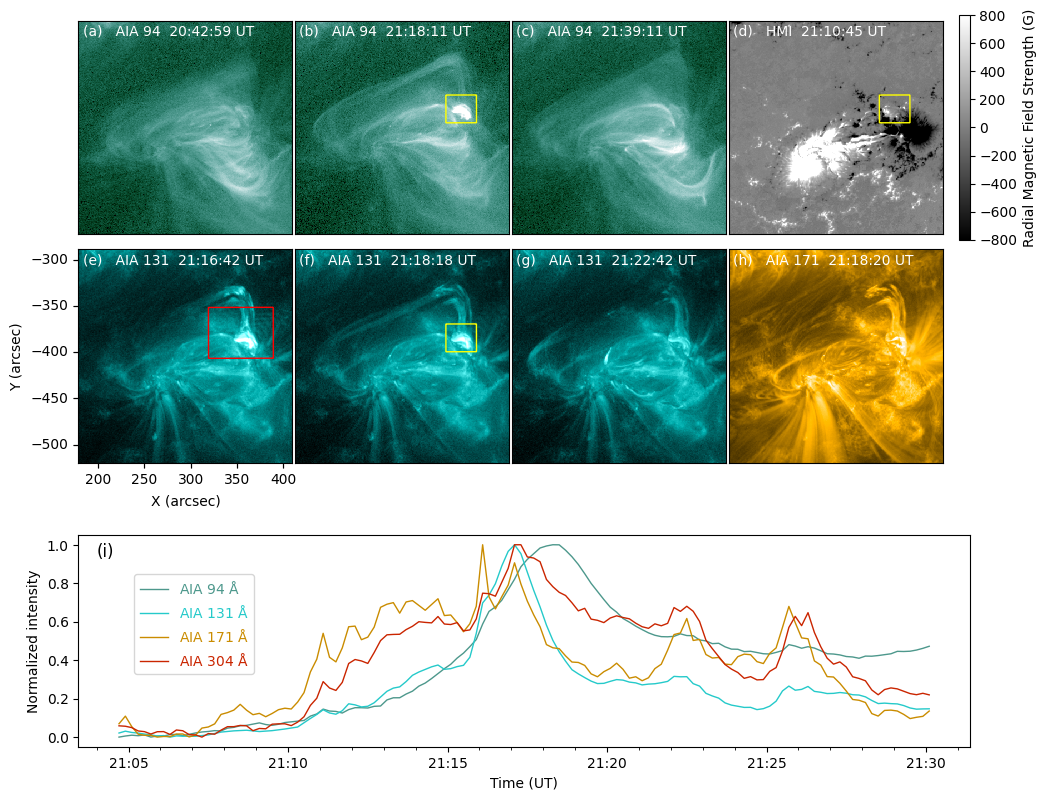

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(11.5,9.5))

# 整体划分为上下两大块：上(3份高度)，下(2份高度)
gs = gridspec.GridSpec(2, 1, height_ratios=[7.5, 3.5], hspace=0.2)

# ---------------- 上半部分：AIA 三幅图 ----------------
# 这里再细分成 1 行 3 列的小网格
gs_top = gridspec.GridSpecFromSubplotSpec(2, 6, subplot_spec=gs[0], wspace=0.02,hspace=0.02,width_ratios=[1,1,1,1,0.05,0.05])
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
#这个标记IRIS观测区域的具体位置，在process_iris.pro文档里有写，导出的矩阵所处的Tx=[320,390]Ty=[-462,-352]范围
#之后读取all_sji_image.sav的时候有一步[330:,:]，把y轴方向裁剪掉了一半，所以现在ty=[-407,-352]
bl2=SkyCoord(Tx=320*u.arcsec, Ty=-407*u.arcsec, frame=map1.coordinate_frame)
tr2=SkyCoord(Tx=390*u.arcsec, Ty=-352*u.arcsec, frame=map1.coordinate_frame)

map_all=[map1,map2,map3,map4,map5,map6,map7,map8]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

#对94去除较差自转
with propagate_with_solar_surface():
    for i in range(8):
        if i!=1:
            smap_all[i]=map_all[i].reproject_to(smap_all[1].wcs,preserve_date_obs=True)
    # smap_all[0]=map1.reproject_to(smap_all[1].wcs,preserve_date_obs=True)
    # smap_all[2]=map3.reproject_to(smap_all[1].wcs,preserve_date_obs=True)

ax_all=[]
for i in range(8):
    r=i//4
    c=i%4
    ax=fig.add_subplot(gs_top[r,c],projection=smap_all[i])
    #ax=fig.add_subplot(gs_top[i],projection=smap_all[i])
    ax_all.append(ax)
    if i==7:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=5000
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==0 or i==1 or i==2:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=300
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==4 or i==5 or i==6:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=2000
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==3:
        im_hmi=smap_all[i].plot(axes=ax_all[i])
        im_hmi.set_clim(-800,800)
    
    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第5张图加X Y轴
    if i == 4:   # 左下角
        #标出IRIS的位置
        smap_all[i].draw_quadrangle(bl2,top_right=tr2,edgecolor='red',axes=ax)
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X (arcsec)')
        #ax.set_xlabel('X(arcsecs)',labelpad=1.1)
        ax.set_ylabel('Y (arcsec)')
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)
        #关掉单位
        ax.coords[0].set_major_formatter('s',show_decimal_unit=False)
        ax.coords[1].set_major_formatter('s',show_decimal_unit=False) 
      
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

cax_d=fig.add_subplot(gs_top[0,5])
cbar_d=fig.colorbar(im_hmi,cax=cax_d)
cbar_d.set_label('Radial Magnetic Field Strength (G)')

bl3=SkyCoord(Tx=342*u.arcsec,Ty=-400*u.arcsec,frame=smap_all[3].coordinate_frame)
tr3=SkyCoord(Tx=375*u.arcsec,Ty=-370*u.arcsec,frame=smap_all[3].coordinate_frame)
smap_all[1].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[1])
smap_all[3].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[3])
smap_all[5].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[5])

ax_all[0].text(0.02,0.93,'(a)   AIA 94  20:42:59 UT',color='white',transform=ax_all[0].transAxes,fontsize=10)
ax_all[1].text(0.02,0.93,'(b)   AIA 94  21:18:11 UT',color='white',transform=ax_all[1].transAxes,fontsize=10)
ax_all[2].text(0.02,0.93,'(c)   AIA 94  21:39:11 UT',color='white',transform=ax_all[2].transAxes,fontsize=10)
ax_all[3].text(0.02,0.93,'(d)   HMI  21:10:45 UT',color='white',transform=ax_all[3].transAxes,fontsize=10)
ax_all[4].text(0.02,0.93,'(e)   AIA 131  21:16:42 UT',color='white',transform=ax_all[4].transAxes,fontsize=10)
ax_all[5].text(0.02,0.93,'(f)   AIA 131  21:18:18 UT',color='white',transform=ax_all[5].transAxes,fontsize=10)
ax_all[6].text(0.02,0.93,'(g)   AIA 131  21:22:42 UT',color='white',transform=ax_all[6].transAxes,fontsize=10)
ax_all[7].text(0.02,0.93,'(h)   AIA 171  21:18:20 UT',color='white',transform=ax_all[7].transAxes,fontsize=10)
# ---------------- 下半部分 ----------------
gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[1], hspace=0.05)

ax8 = fig.add_subplot(gs_bottom[0])

name_list=[r'AIA 94 $\mathrm{\AA}$',r'AIA 131 $\mathrm{\AA}$',
           r'AIA 171 $\mathrm{\AA}$',r'AIA 193 $\mathrm{\AA}$',
           r'AIA 211 $\mathrm{\AA}$',r'AIA 304 $\mathrm{\AA}$',r'AIA 335 $\mathrm{\AA}$']
lines=[]
linstyle=['-','-']

#从AIA那几个波段的cmap里采集颜色用来画曲线
color=[]
color_list=['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335']
for i in range(7):
    cmap=plt.get_cmap(color_list[i])
    middle_color=cmap(0.55)
    color.append(middle_color)
#画七条AIA曲线
for i in range(7):
    if i==1 or i==2 or i==0 or i==5:
        line,=ax8.plot(intensity[i,20:],color=color[i],label=name_list[i],linewidth=1,linestyle=linstyle[i%2])
        lines.append(line)
legend=ax8.legend(loc='center', bbox_to_anchor=(0.13, 0.58),fontsize=10)
#让legend里的文字颜色和曲线颜色一致
for text,line in zip(legend.get_texts(),lines):
    text.set_color(line.get_color())

corr_x=np.zeros(6)
#第一个时刻对应21：00：42，最后一个时刻对应21：27：06
for i in range(len(corr_x)):
    corr_x[i]=(i*300+18)/12
ax8.set_ylabel('Normalized intensity')
ax8.set_xticks(ticks=corr_x,labels=['21:05','21:10','21:15','21:20','21:25','21:30'])
ax8.text(0.02,0.9,'(i)',color='black',transform=ax8.transAxes,fontsize=12)
import matplotlib.ticker as ticker
ax8.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax8.yaxis.set_minor_locator(ticker.NullLocator())       # 禁止 y 轴小刻度
ax8.set_xlabel('Time (UT)')
plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig5\aia_image_intensity_curve.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

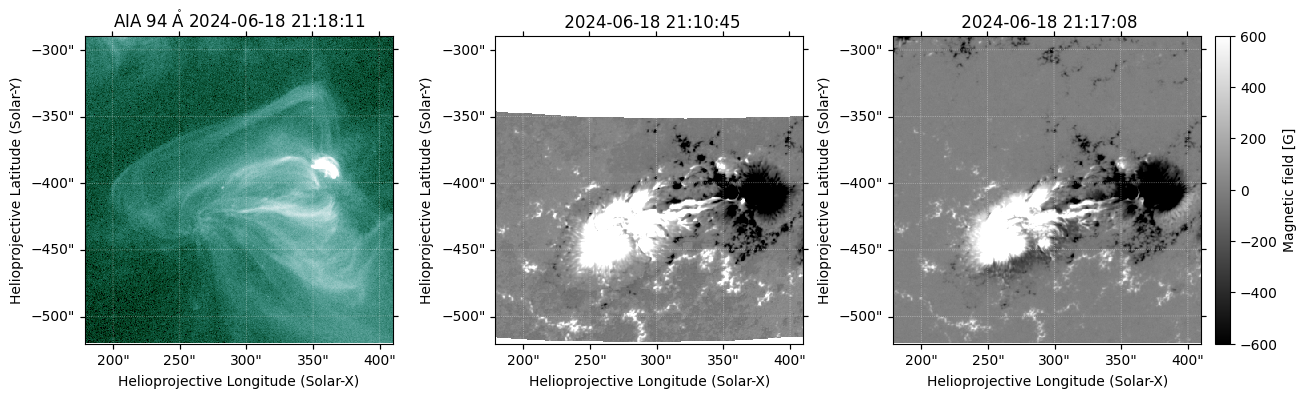

In [7]:
br_map=sunpy.map.Map(r'C:\Users\xiao\Downloads\JSOC_20260313_002510\hmi.sharp_cea_720s.11376.20240618_211200_TAI.Br.fits')
br_map_remap=br_map.reproject_to(smap_all[1].wcs,preserve_date_obs=True)
fig = plt.figure(figsize=(15,4))
ax1=fig.add_subplot(1,3,1, projection=smap_all[1])
im1=smap_all[1].plot(axes=ax1)
ax2 = fig.add_subplot(1,3,2, projection=br_map_remap)
im2=br_map_remap.plot(axes=ax2)
im2.set_clim(-600,600)
# cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
# cbar2.set_label('Magnetic field [G]')
ax3=fig.add_subplot(1,3,3, projection=smap_all[3])
im3=smap_all[3].plot(axes=ax3)
im3.set_clim(-600,600)
cbar3 = fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_label('Magnetic field [G]')